# Exercise: how hot is that star? - Blackbody radiation and Planck's law

Stars radiate, to a good approximation, like **blackbodies**: objects whose emission spectrum depends only on their temperature. This is why stars have different colors: a cool red giant and a hot blue supergiant are both "just" blackbodies at different temperatures. In this exercise you'll compute and explore that spectrum yourself.

**Concepts used:** functions & docstrings, `if`/`elif`/`else`, `for` loops, dictionaries, list comprehensions, i.e. everything from the last few notebooks, applied to real physics.

*Note: You can use `math.exp`, `math.pi`, etc. from the standard `math` module for mathematical expression. We'll see a more *


In [1]:
import math # This is needed to calculate and exponential, get the value of pi, etc ... 


## Warm-up: Wien's displacement law

The hotter a blackbody, the *shorter* (bluer) the wavelength at which it emits most strongly. This is quantified by **Wien's displacement law**:

$$\lambda_{\rm {max}} = \dfrac{b}{T}$$

where $T$ is the temperature in Kelvin, $b = 2.8977719 \times 10^{-3}\ \rm{m·K}$ is Wien's constant, and $\lambda_{\rm {max}}$ comes out in meters.


**Task 1.** Write a function `wien_peak_wavelength(T)` that returns $\lambda_{max}$ **in meters**. Give it a docstring.


In [2]:
# Task 1: wien_peak_wavelength(T)

def wien_peak_wavelength(T): 
    """
    Calculate the peak wavelength of blackbody radiation using Wien's displacement law.

    Parameters:
    T (float): Temperature in Kelvin.

    Returns:
    float: Peak wavelength in meters.
    """
    # Wien's displacement constant in meters Kelvin
    b = 2.897771955e-3  # m*K
    return b / T

# testing the function
lbda_peak = wien_peak_wavelength(5000)  # Example temperature in Kelvin
print(f"The peak wavelength for a temperature of 5000 K is: {lbda_peak} meters")
print(f"The peak wavelength for a temperature of 5000 K is: {lbda_peak * 1e9:.2f} nanometers")  # Convert to nanometers
print("The peak wavelength for a temperature of 5000 K is: %.2f Angstroms" % (lbda_peak * 1e10))  # Convert to Angstroms ; Alternative formating using the % operator

The peak wavelength for a temperature of 5000 K is: 5.79554391e-07 meters
The peak wavelength for a temperature of 5000 K is: 579.55 nanometers
The peak wavelength for a temperature of 5000 K is: 5795.54 Angstroms


In [11]:
print(f'Lambda_peak: {lbda_peak:.5e} or in nm {lbda_peak * 1.e9 :.2f} m') 

Lambda_peak: 5.79554e-07 or in nm 579.55 m


**Task 2.** Here is a small "catalog" of stars, as a list of dictionaries:

```python
stars = [
    {"name": "Sun", "T": 5778},
    {"name": "Betelgeuse (red supergiant)", "T": 3780},
    {"name": "Rigel (blue supergiant)", "T": 12100},
]
```

Loop over `stars`, and for each one print its name and its peak wavelength **converted to nanometers** (1 m = 1e9 nm), using the function from Task 1.


In [15]:
stars = [
    {"name": "Sun", "T": 5778},
    {"name": "Betelgeuse (red supergiant)", "T": 3780},
    {"name": "Rigel (blue supergiant)", "T": 12100},
]
# Task 2: loop over stars and print each peak wavelength in nm
for star in stars:
#     print(star)
    lbda_peak = wien_peak_wavelength(star["T"])
    print(f"The peak wavelength for {star['name']} (T={star['T']} K) is: {lbda_peak * 1e9:.2f} nanometers")

print('-------------------------')
# Iterate not over elements but over indices 
for i in range(len(stars)):
#     print(star)
    star = stars[i]
    lbda_peak = wien_peak_wavelength(star["T"])
    print(f"The peak wavelength for {star['name']} (T={star['T']} K) is: {lbda_peak * 1e9:.2f} nanometers")


The peak wavelength for Sun (T=5778 K) is: 501.52 nanometers
The peak wavelength for Betelgeuse (red supergiant) (T=3780 K) is: 766.61 nanometers
The peak wavelength for Rigel (blue supergiant) (T=12100 K) is: 239.49 nanometers
-------------------------
The peak wavelength for Sun (T=5778 K) is: 501.52 nanometers
The peak wavelength for Betelgeuse (red supergiant) (T=3780 K) is: 766.61 nanometers
The peak wavelength for Rigel (blue supergiant) (T=12100 K) is: 239.49 nanometers


**Task 3 (bonus, quick).** The visible spectrum is roughly 380-700 nm; below that is ultraviolet, above it is infrared. Write a function `classify_band(wavelength_nm)` that takes a wavelength in nm and returns the string `"ultraviolet"`, `"visible"`, or `"infrared"` using `if`/`elif`/`else`. Don't forget the docstring. Then re-run your loop from Task 2, adding the band for each star.


In [16]:
# Task 3 (bonus): classify_band + updated loop

def classify_band(lbda_peak_nm):   
    """
    Classify the peak wavelength into a spectral band.

    Parameters:
    lbda_peak_nm (float): Peak wavelength in nanometers.

    Returns:
    str: Spectral band classification.
    """
    if lbda_peak_nm < 380:
        return "Ultraviolet"
    elif 400 <= lbda_peak_nm < 700:  # equivalent to ((400 <= lbda_peak_nm) & (lbda_peak_nm < 700) )
        return "Visible"
    else:
        return "Infrared"

for star in stars:
    lbda_peak = wien_peak_wavelength(star["T"])
    lbda_peak_nm = lbda_peak * 1e9  # Convert to nanometers
    band = classify_band(lbda_peak_nm)
    print(f"The peak wavelength for {star['name']} (T={star['T']} K) is: {lbda_peak_nm:.2f} nanometers, which is in the {band} band.")


The peak wavelength for Sun (T=5778 K) is: 501.52 nanometers, which is in the Visible band.
The peak wavelength for Betelgeuse (red supergiant) (T=3780 K) is: 766.61 nanometers, which is in the Infrared band.
The peak wavelength for Rigel (blue supergiant) (T=12100 K) is: 239.49 nanometers, which is in the Ultraviolet band.


## Main challenge: plotting the full spectrum with Planck's law

Wien's law only gives you the *peak*. The full shape of the blackbody spectrum is given by **Planck's law**, giving the spectral radiance $B(\lambda, T)$ at wavelength $\lambda$ (in meters) and temperature $T$ (in Kelvin):

$$B(\lambda, T) = \dfrac{2hc^2}{\lambda^5} \cdot \dfrac{1}{e^{\frac{hc}{\lambda k_B T}} - 1}$$

with:
- $h = 6.62607015 \times 10^{-34}\ \rm{J·s}$ (Planck constant)
- $c = 2.99792458 \times 10^{8}\ \rm{m/s}$ (speed of light)
- $k_B = 1.380649 \times 10^{-23}\ \rm{J/K}$ (Boltzmann constant)

**Task 4.** Write a function `planck_law(wavelength, T)` implementing the formula above (`wavelength` in meters). Define `h`, `c`, `k_B` as local variables inside the function. Use `math.exp` for the exponential. Add a docstring.


In [17]:
# Task 4: planck_law(wavelength, T)

def planck_law(wavelength, T):
    """
    Calculate the spectral radiance of a blackbody at a given wavelength and temperature using Planck's law.

    Parameters:
    wavelength (float): Wavelength in meters.
    T (float): Temperature in Kelvin.

    Returns:
    float: Spectral radiance in W·sr⁻¹·m⁻³.
    """
    h = 6.62607015e-34  # Planck's constant in J·s
    c = 2.99792458e8    # Speed of light in m/s
    k = 1.380649e-23    # Boltzmann's constant in J/K

    exponent = (h * c) / (wavelength * k * T)
    spectral_radiance = (2 * h * c**2) / (wavelength**5 * (math.exp(exponent) - 1))
    
    return spectral_radiance


**Task 5.** Build a grid of wavelengths from 100 nm to 3000 nm in steps of 50 nm, **as a list comprehension**, directly in meters (i.e. the final list should already be in meters, not nm). Call it `wavelengths_m`.

*Hint: first build the nm values with `range`, then convert with a comprehension.*


In [21]:
# Task 5: wavelengths_m, a list comprehension from 100nm to 3000nm (step 50nm), in meters

lbda_start_nm = 100
lbda_end_nm = 3000
wavelengths_m = [lbda * 1e-9 for lbda in range(lbda_start_nm, lbda_end_nm + 1, 50)]  # Convert nm to meters 
wavelengths_m[0:3]


[1.0000000000000001e-07, 1.5000000000000002e-07, 2.0000000000000002e-07]

**Task 6.** Using another list comprehension, compute the Sun's spectral radiance (`T = 5778` K) at every wavelength in `wavelengths_m`. Call the result `radiances_sun`.


In [22]:
# Task 6: radiances_sun, a list comprehension calling planck_law

radiances_sun = [planck_law(wavelength, 5778) for wavelength in wavelengths_m]  # Sun's temperature is 5778 K


**Task 7 — find the peak "by hand".** Without using any built-in shortcut like `max()`, write a `for` loop (with `enumerate`) that scans through `radiances_sun` and keeps track of the largest value seen so far, and the wavelength it corresponds to. At the end, print the wavelength (in nm) of the peak.

Then compare it to the prediction from `wien_peak_wavelength` (Task 1) for the same temperature. They should be close, but not identical — why not? (One sentence answer, as a comment or in a markdown cell.)


In [23]:
max_radiance_index = 0
max_radiance_value = radiances_sun[0]
for i in range(len(radiances_sun)):
    radiance = radiances_sun[i]
    if radiance > max_radiance_value:
        max_radiance_value = radiance
        max_radiance_index = i


In [24]:
# Task 7: find the peak of radiances_sun with a for loop + enumerate, then compare to Wien's law
max_radiance_index = 0
max_radiance_value = radiances_sun[0]
for i, radiance in enumerate(radiances_sun):
    if radiance > max_radiance_value:
        max_radiance_value = radiance
        max_radiance_index = i

print(f"The peak radiance is {max_radiance_value:.2e} W sr-1 m-3 at index {max_radiance_index} \n, which corresponds to a wavelength of {wavelengths_m[max_radiance_index] * 1e9:.2f} nm.")

# Compare to Wien's law
wien_peak = wien_peak_wavelength(5778)
print(f"Wien's law predicts a peak wavelength of {wien_peak * 1e9:.2f} nm.")


The peak radiance is 2.64e+13 W sr-1 m-3 at index 8 
, which corresponds to a wavelength of 500.00 nm.
Wien's law predicts a peak wavelength of 501.52 nm.


### Bonus (optional)

If you're curious, repeat Task 6 and Task 7 for `Betelgeuse` and `Rigel` from the `stars` catalog above (loop over `stars` instead of hard-coding the temperature), and check that the hotter star peaks at shorter wavelengths.

If you'd like to *see* the curve rather than just read the numbers, here is a ready-to-run cell using `matplotlib` (a plotting library we haven't covered yet in class; this one is just for fun, you don't need to understand every line):


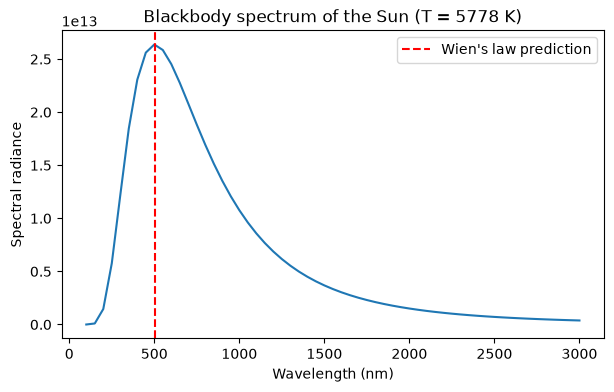

In [14]:
import matplotlib.pyplot as plt

# assumes you have completed Task 4-6 above: planck_law, wavelengths_m, radiances_sun
wavelengths_nm = [w * 1e9 for w in wavelengths_m]

plt.figure(figsize=(7, 4))
plt.plot(wavelengths_nm, radiances_sun)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Spectral radiance")
plt.title("Blackbody spectrum of the Sun (T = 5778 K)")
plt.axvline(wien_peak_wavelength(5778) * 1e9, color="red", linestyle="--",
            label="Wien's law prediction")
plt.legend()
plt.show()


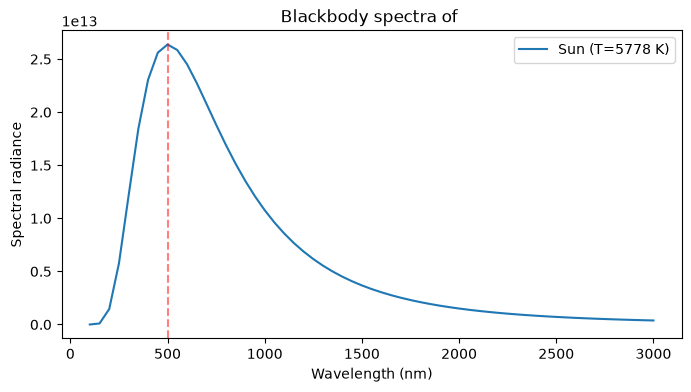

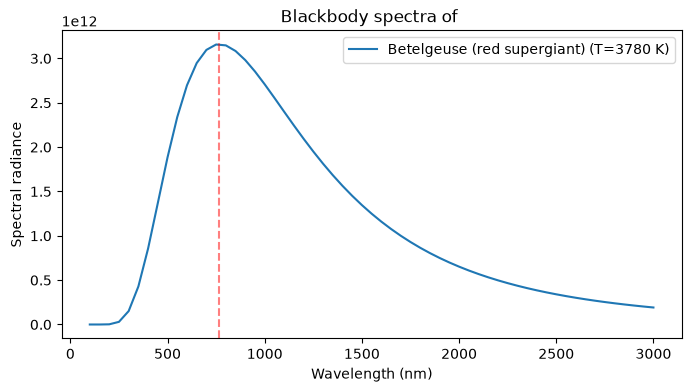

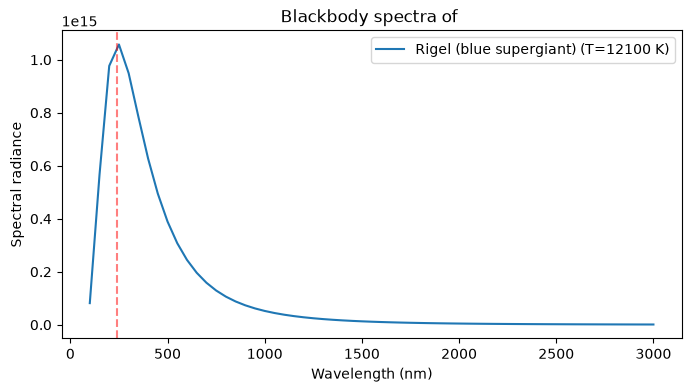

In [17]:
# Repeat different tasks for each of the stars in the stars list, and plot their blackbody spectra on the same graph

for star in stars:
    plt.figure(figsize=(8, 4))
    radiances_star = [planck_law(wavelength, star["T"]) for wavelength in wavelengths_m]
    plt.plot(wavelengths_nm, radiances_star, label=f"{star['name']} (T={star['T']} K)")
    plt.axvline(wien_peak_wavelength(star["T"]) * 1e9, color="red", linestyle="--", alpha=0.5)
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Spectral radiance")
    plt.title("Blackbody spectra of %.s" % star['name'])
    plt.legend()

## What you practiced

- Writing small, well-documented functions (`wien_peak_wavelength`, `planck_law`, `classify_band`) — each with a clear docstring.
- Looping over a list of dictionaries (your mini star catalog).
- Building data with list comprehensions (`wavelengths_m`, `radiances_sun`).
- A manual "running max" search with `for` + `enumerate`, and cross-checking a numerical result against an analytical formula. Testing your function agains "known results" (Here the lambda of the max using Wien's law) is an habit worth keeping for the rest of the course (and beyond).
 